### Terenary Search


In [1]:
def terenarySearch(arr, lo, hi,target):
    if lo > hi:
        return -1

    mid1 = lo + (hi - lo) // 3
    mid2 = hi - (hi - lo) // 3

    while mid1 <= hi and mid2 >= lo:
        if arr[mid1] == target:
            return mid1
        if arr[mid2] == target:
            return mid2

        if arr[mid1] > target:
            hi = mid1 - 1
        else:
            lo = mid1 + 1

        if arr[mid2] > target:
            hi = mid2 - 1
        else:
            lo = mid2 + 1

    return -1

### K Arry Search

In [2]:
def KarrySearch(arr, target, k):
    def search(lo, hi):
        if lo > hi:
            return -1

        size = hi - lo + 1
        prev = lo
        for i in range(1, k):
            m = lo + (size * i) // k
            if m > hi:
                m = hi
            if arr[m] == target:
                return m
            if arr[m] > target:
                return search(prev, m - 1)
            prev = m + 1

        return search(prev, hi)

    return search(0, len(arr) - 1)

In [3]:
def KarrySearchComparisons(arr, target, k):
    count = 0

    def search(lo, hi):
        nonlocal count
        if lo > hi:
            return

        size = hi - lo + 1
        prev = lo
        for i in range(1, k):
            m = lo + (size * i) // k
            if m > hi:
                m = hi
            count += 1
            if arr[m] == target:
                return
            count += 1
            if arr[m] > target:
                search(prev, m - 1)
                return
            prev = m + 1

        search(prev, hi)

    search(0, len(arr) - 1)
    return count

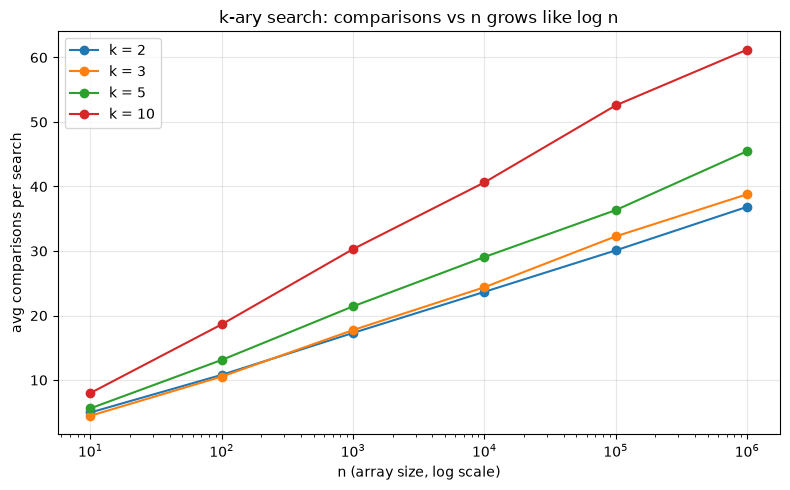

In [4]:
import random
import matplotlib.pyplot as plt

def measure_comparisons(k, sizes, trials=300, seed=42):

    rng = random.Random(seed)
    avg_counts = []
    for n in sizes:
        arr = list(range(n))
        total = 0
        for _ in range(trials):
            target = rng.randrange(n)
            total += KarrySearchComparisons(arr, target, k)
        avg_counts.append(total / trials)
    return avg_counts

sizes = [10**p for p in range(1, 7)]     # 10 ... 1,000,000

plt.figure(figsize=(8, 5))
for k in (2, 3, 5, 10):
    counts = measure_comparisons(k, sizes)
    plt.semilogx(sizes, counts, 'o-', label=f'k = {k}')

plt.xlabel('n (array size, log scale)')
plt.ylabel('avg comparisons per search')
plt.title('k-ary search: comparisons vs n grows like log n')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('kary_scaling.png', dpi=120)
plt.show()

### Problem 4

In [5]:
def solve_squared_square(n, max_size=None, step_limit=500_000):
    if max_size is None:
        max_size = n - 1  # exclude the trivial single n x n "square"

    heights = [0] * n
    used = set()
    squares = []
    steps = 0

    def max_fit(x, y):
        s = 0
        while x + s < n and heights[x + s] == y:
            s += 1
        return min(s, n - y, max_size)

    def backtrack():
        nonlocal steps
        steps += 1
        if steps > step_limit:
            raise TimeoutError

        if all(h == n for h in heights):
            return True

        y = min(heights)
        x = heights.index(y)
        s_max = max_fit(x, y)

        for s in range(s_max, 0, -1):
            if s in used:
                continue
            for i in range(s):
                heights[x + i] = y + s
            used.add(s)
            squares.append((x, y, s))

            if backtrack():
                return True

            used.discard(s)
            squares.pop()
            for i in range(s):
                heights[x + i] = y

        return False

    try:
        found = backtrack()
    except TimeoutError:
        return None, steps, True

    return (squares if found else None), steps, False

In [6]:
def verify_partition(n, squares):

    if not squares:
        return False

    sizes = [s for (_, _, s) in squares]
    if len(set(sizes)) != len(sizes):
        return False

    covered = [[False] * n for _ in range(n)]
    for (x, y, s) in squares:
        if x < 0 or y < 0 or x + s > n or y + s > n:
            return False
        for i in range(x, x + s):
            for j in range(y, y + s):
                if covered[i][j]:
                    return False
                covered[i][j] = True

    return all(all(row) for row in covered)

squares, steps, timed_out = solve_squared_square(5)
print(f"n=5  -> {'found: ' + str(squares) if squares else 'no partition exists'}  ({steps} steps)")

# If the search does find something, it must pass the independent checker.
if squares:
    assert verify_partition(5, squares)

n=5  -> no partition exists  (15 steps)


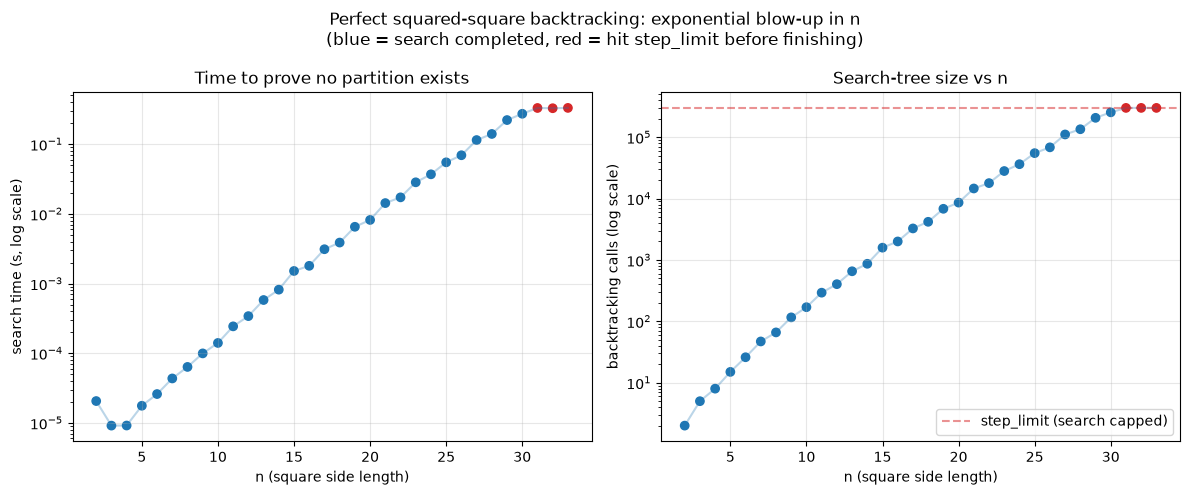

In [7]:
import time
import matplotlib.pyplot as plt

STEP_LIMIT = 300_000
ns = list(range(2, 34))

elapsed_times = []
step_counts = []
timed_out_flags = []

for n in ns:
    t0 = time.perf_counter()
    result, steps, timed_out = solve_squared_square(n, step_limit=STEP_LIMIT)
    elapsed_times.append(time.perf_counter() - t0)
    step_counts.append(steps)
    timed_out_flags.append(timed_out)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

colors = ['tab:red' if t else 'tab:blue' for t in timed_out_flags]
ax1.scatter(ns, elapsed_times, c=colors)
ax1.plot(ns, elapsed_times, '-', color='tab:blue', alpha=0.3)
ax1.set_yscale('log')
ax1.set_xlabel('n (square side length)')
ax1.set_ylabel('search time (s, log scale)')
ax1.set_title('Time to prove no partition exists')
ax1.grid(True, alpha=0.3)

ax2.scatter(ns, step_counts, c=colors)
ax2.plot(ns, step_counts, '-', color='tab:blue', alpha=0.3)
ax2.axhline(STEP_LIMIT, color='tab:red', linestyle='--', alpha=0.5, label='step_limit (search capped)')
ax2.set_yscale('log')
ax2.set_xlabel('n (square side length)')
ax2.set_ylabel('backtracking calls (log scale)')
ax2.set_title('Search-tree size vs n')
ax2.legend()
ax2.grid(True, alpha=0.3)

fig.suptitle('Perfect squared-square backtracking: exponential blow-up in n\n'
             '(blue = search completed, red = hit step_limit before finishing)')
plt.tight_layout()
plt.savefig('squared_square_scaling.png', dpi=120)
plt.show()

### Problem 1

#### Binary Search

n=16     steps=5   log2(n)=4.00
n=32     steps=6   log2(n)=5.00
n=64     steps=7   log2(n)=6.00
n=128    steps=8   log2(n)=7.00
n=256    steps=9   log2(n)=8.00
n=512    steps=10  log2(n)=9.00
n=1024   steps=11  log2(n)=10.00
n=2048   steps=12  log2(n)=11.00
n=4096   steps=13  log2(n)=12.00
n=8192   steps=14  log2(n)=13.00
n=16384  steps=15  log2(n)=14.00
n=32768  steps=16  log2(n)=15.00
n=65536  steps=17  log2(n)=16.00
n=131072 steps=18  log2(n)=17.00
n=262144 steps=19  log2(n)=18.00
n=524288 steps=20  log2(n)=19.00


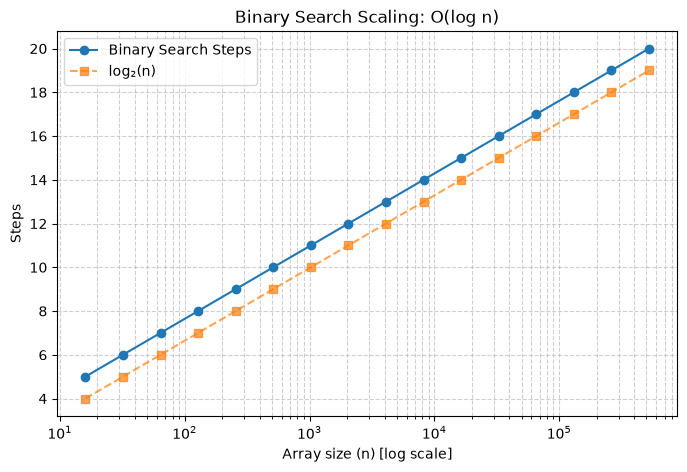

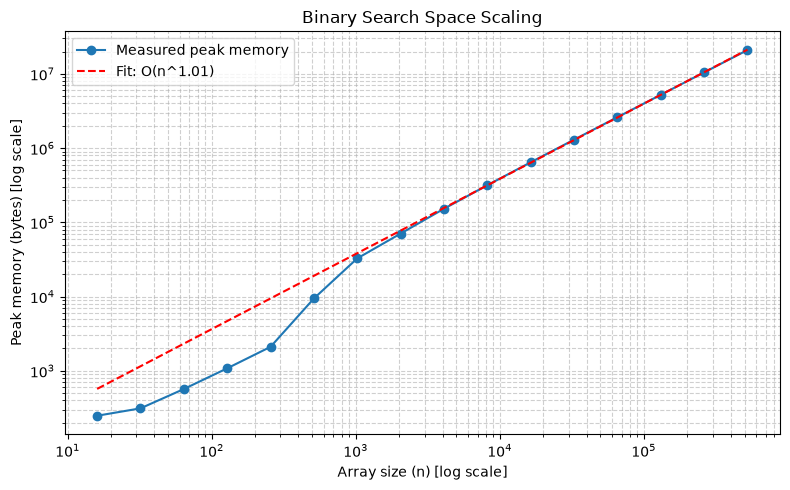

fitted exponent: 1.012 (theory: O(n))


In [8]:
import math
import tracemalloc
import numpy as np
import matplotlib.pyplot as plt

def binary_search(arr, target):
    low, high = 0, len(arr) - 1
    steps = 0

    while low <= high:
        steps += 1
        mid = (low + high) // 2

        if arr[mid] == target:
            return mid, steps
        elif arr[mid] < target:
            low = mid + 1
        else:
            high = mid - 1

    return -1, steps

sizes = [2**k for k in range(4, 20)]
steps_list = []
log_values = []

for n in sizes:
    arr = list(range(n))
    target = arr[-1]
    _, steps = binary_search(arr, target)
    steps_list.append(steps)
    log_values.append(math.log2(n))
    print(f"n={n:<6} steps={steps:<3} log2(n)={math.log2(n):.2f}")

plt.figure(figsize=(8, 5))
plt.plot(sizes, steps_list, 'o-', label="Binary Search Steps")
plt.plot(sizes, log_values, 's--', label="log₂(n)", alpha=0.7)

plt.xscale("log")
plt.xlabel("Array size (n) [log scale]")
plt.ylabel("Steps")
plt.title("Binary Search Scaling: O(log n)")
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.show()

mem_sizes = [2**k for k in range(4, 20)]
peak_memory = []

for n in mem_sizes:
    tracemalloc.start()
    arr = list(range(n))
    target = arr[-1]
    binary_search(arr, target)
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    peak_memory.append(peak)

fit_start = len(mem_sizes) // 2
log_n = np.log(mem_sizes[fit_start:])
log_mem = np.log(peak_memory[fit_start:])
exponent, intercept = np.polyfit(log_n, log_mem, 1)
fit = np.exp(intercept) * np.array(mem_sizes, dtype=float) ** exponent

plt.figure(figsize=(8, 5))
plt.loglog(mem_sizes, peak_memory, 'o-', label='Measured peak memory')
plt.loglog(mem_sizes, fit, 'r--', label=f'Fit: O(n^{exponent:.2f})')
plt.xlabel("Array size (n) [log scale]")
plt.ylabel("Peak memory (bytes) [log scale]")
plt.title("Binary Search Space Scaling")
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

print(f"fitted exponent: {exponent:.3f} (theory: O(n))")

#### Bubble Sort

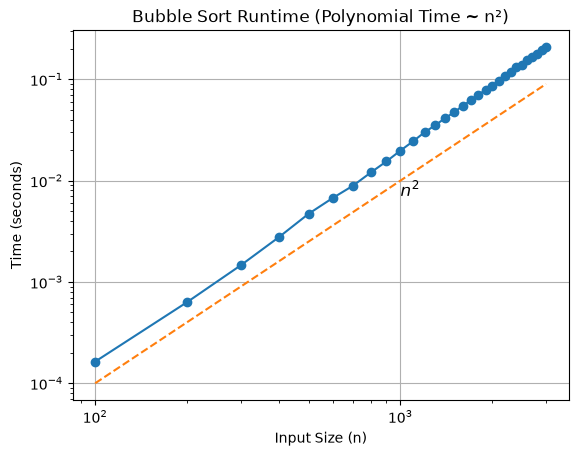

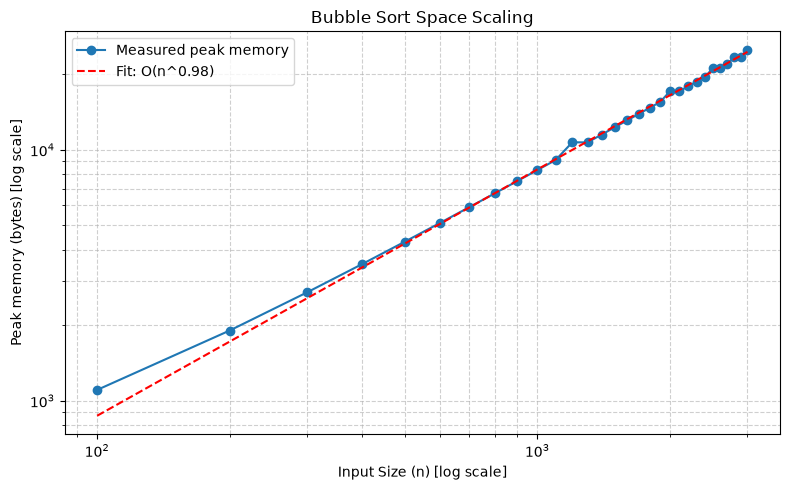

fitted exponent: 0.982 (theory: O(n))


In [9]:
import time
import random
import tracemalloc
import matplotlib.pyplot as plt
import numpy as np

def bubble_sort(arr):
    n = len(arr)
    for i in range(n):
        for j in range(n - i - 1):
            if arr[j] > arr[j + 1]:
                arr[j], arr[j + 1] = arr[j + 1], arr[j]

input_sizes = list(range(100, 3100, 100))
times = []

for n in input_sizes:
    test_array = [random.randint(0, 1000) for _ in range(n)]
    start = time.time()
    bubble_sort(test_array)
    end = time.time()
    times.append(end - start)

plt.loglog(input_sizes, times, marker='o')
plt.loglog(input_sizes, 1e-8*np.array(input_sizes)**(2), linestyle='--')
plt.title('Bubble Sort Runtime (Polynomial Time ~ n²)')
plt.xlabel('Input Size (n)')
plt.ylabel('Time (seconds)')
plt.text(1e3, 7e-3, r'$n^2$', fontsize=12, color='black')
plt.grid(True)
plt.show()

np.random.seed(0)
_ = np.random.randint(0, 1000, size=10)

mem_sizes = list(range(100, 3100, 100))
peak_memory = []

for n in mem_sizes:
    tracemalloc.start()
    test_array = np.random.randint(0, 1000, size=n)
    bubble_sort(test_array)
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    peak_memory.append(peak)

fit_start = len(mem_sizes) // 4
log_n = np.log(mem_sizes[fit_start:])
log_mem = np.log(peak_memory[fit_start:])
exponent, intercept = np.polyfit(log_n, log_mem, 1)
fit = np.exp(intercept) * np.array(mem_sizes, dtype=float) ** exponent

plt.figure(figsize=(8, 5))
plt.loglog(mem_sizes, peak_memory, 'o-', label='Measured peak memory')
plt.loglog(mem_sizes, fit, 'r--', label=f'Fit: O(n^{exponent:.2f})')
plt.title('Bubble Sort Space Scaling')
plt.xlabel('Input Size (n) [log scale]')
plt.ylabel('Peak memory (bytes) [log scale]')
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

print(f"fitted exponent: {exponent:.3f} (theory: O(n))")

#### FFT Scaling

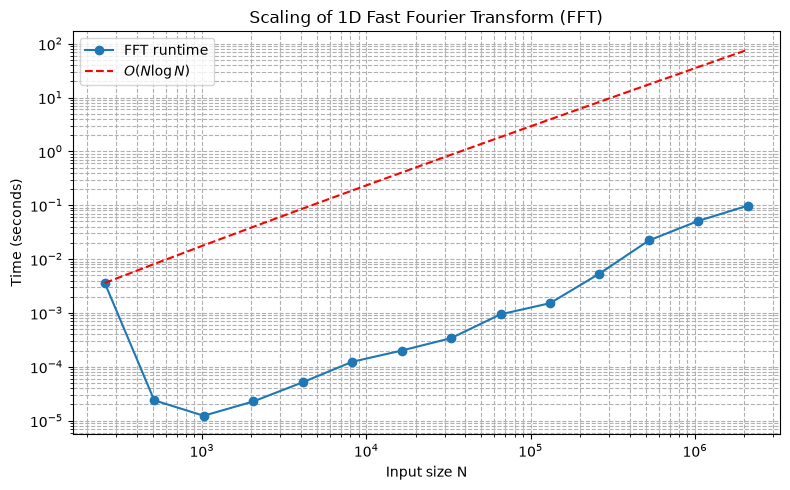

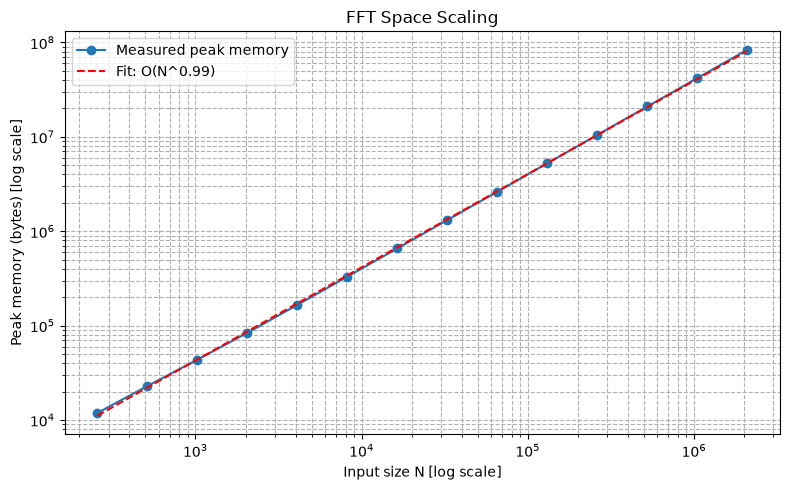

fitted exponent: 0.988 (theory: O(N))


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import time
import tracemalloc

sizes = 2 ** np.arange(8, 22)
times = []

for N in sizes:
    x = np.random.rand(N)
    start = time.perf_counter()
    np.fft.fft(x)
    end = time.perf_counter()
    times.append(end - start)

plt.figure(figsize=(8, 5))
plt.loglog(sizes, times, 'o-', label='FFT runtime')
plt.loglog(sizes, times[0] * sizes * np.log2(sizes) / (sizes[0] * np.log2(sizes[0])), 'r--', label=r'$O(N \log N)$')
plt.xlabel("Input size N")
plt.ylabel("Time (seconds)")
plt.title("Scaling of 1D Fast Fourier Transform (FFT)")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.show()

mem_sizes = 2 ** np.arange(8, 22)
peak_memory = []

for N in mem_sizes:
    tracemalloc.start()
    x = np.random.rand(N)
    np.fft.fft(x)
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    peak_memory.append(peak)

log_n = np.log(mem_sizes)
log_mem = np.log(peak_memory)
exponent, intercept = np.polyfit(log_n, log_mem, 1)
fit = np.exp(intercept) * mem_sizes.astype(float) ** exponent

plt.figure(figsize=(8, 5))
plt.loglog(mem_sizes, peak_memory, 'o-', label='Measured peak memory')
plt.loglog(mem_sizes, fit, 'r--', label=f'Fit: O(N^{exponent:.2f})')
plt.xlabel("Input size N [log scale]")
plt.ylabel("Peak memory (bytes) [log scale]")
plt.title("FFT Space Scaling")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.show()

print(f"fitted exponent: {exponent:.3f} (theory: O(N))")

#### Matrix Multiplication

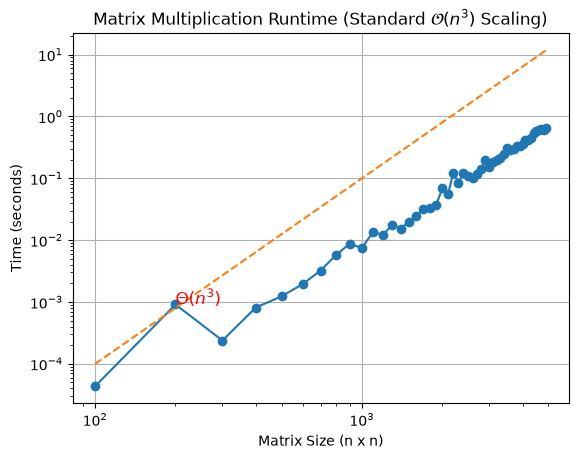

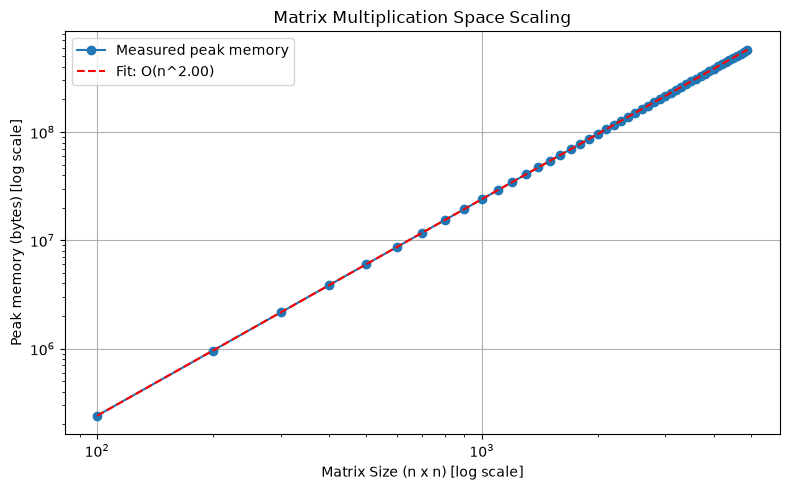

fitted exponent: 2.000 (theory: O(n^2))


In [11]:
import numpy as np
import time
import tracemalloc
import matplotlib.pyplot as plt

sizes = list(range(100, 5000, 100))
times = []

for n in sizes:
    A = np.random.rand(n, n)
    B = np.random.rand(n, n)

    start = time.time()
    C = np.dot(A, B)
    end = time.time()

    times.append(end - start)

plt.loglog(sizes, times, marker='o')
plt.loglog(sizes, 1e-10*np.array(sizes)**3, linestyle='--')
plt.title('Matrix Multiplication Runtime (Standard $\\mathcal{O}(n^3)$ Scaling)')
plt.xlabel('Matrix Size (n x n)')
plt.ylabel('Time (seconds)')
plt.grid(True)

plt.text(sizes[1], times[1], r'$\Theta(n^3)$', fontsize=12, color='red')

plt.show()

mem_sizes = list(range(100, 5000, 100))
peak_memory = []

for n in mem_sizes:
    tracemalloc.start()
    A = np.random.rand(n, n)
    B = np.random.rand(n, n)
    C = np.dot(A, B)
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    peak_memory.append(peak)

log_n = np.log(mem_sizes)
log_mem = np.log(peak_memory)
exponent, intercept = np.polyfit(log_n, log_mem, 1)
fit = np.exp(intercept) * np.array(mem_sizes, dtype=float) ** exponent

plt.figure(figsize=(8, 5))
plt.loglog(mem_sizes, peak_memory, 'o-', label='Measured peak memory')
plt.loglog(mem_sizes, fit, 'r--', label=f'Fit: O(n^{exponent:.2f})')
plt.title('Matrix Multiplication Space Scaling')
plt.xlabel('Matrix Size (n x n) [log scale]')
plt.ylabel('Peak memory (bytes) [log scale]')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"fitted exponent: {exponent:.3f} (theory: O(n^2))")

#### Subset Sum

n=5  time=0.00001 sec
n=6  time=0.00001 sec
n=7  time=0.00001 sec
n=8  time=0.00002 sec
n=9  time=0.00004 sec
n=10  time=0.00009 sec
n=11  time=0.00018 sec
n=12  time=0.00034 sec
n=13  time=0.00066 sec
n=14  time=0.00133 sec
n=15  time=0.00276 sec
n=16  time=0.00472 sec
n=17  time=0.00932 sec
n=18  time=0.01901 sec
n=19  time=0.03714 sec
n=20  time=0.07366 sec


n=21  time=0.14546 sec


n=22  time=0.29875 sec


n=23  time=0.58773 sec


n=24  time=1.15579 sec


n=25  time=2.29609 sec


n=26  time=4.54717 sec


n=27  time=9.24532 sec


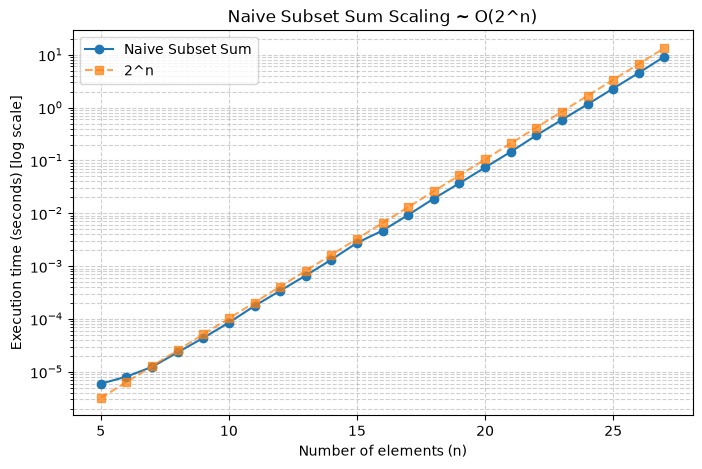

n=5  max recursion depth=5
n=6  max recursion depth=6
n=7  max recursion depth=7
n=8  max recursion depth=8
n=9  max recursion depth=9
n=10  max recursion depth=10
n=11  max recursion depth=11
n=12  max recursion depth=12
n=13  max recursion depth=13
n=14  max recursion depth=14
n=15  max recursion depth=15
n=16  max recursion depth=16


n=17  max recursion depth=17
n=18  max recursion depth=18
n=19  max recursion depth=19
n=20  max recursion depth=20


n=21  max recursion depth=21


n=22  max recursion depth=22


n=23  max recursion depth=23


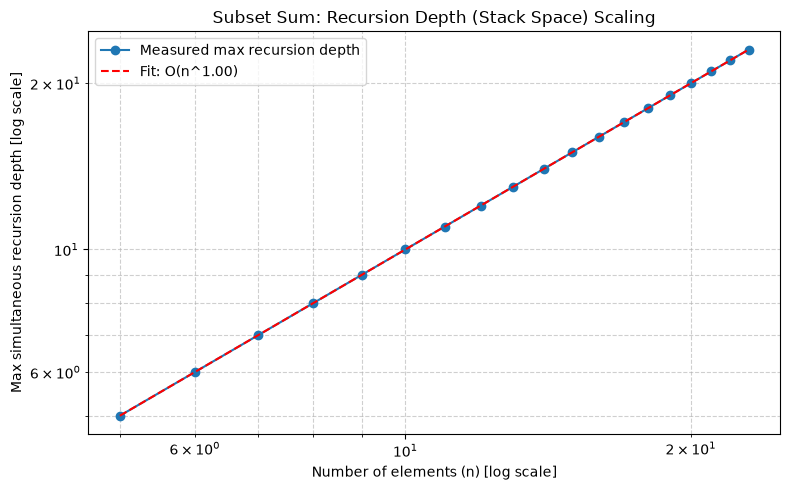

fitted exponent: 1.000 (theory: O(n), even though time is O(2^n))


In [12]:
import time
import numpy as np
import matplotlib.pyplot as plt

def subset_sum(nums, target, i=0):
    if target == 0:
        return True
    if i >= len(nums) or target < 0:
        return False

    include = subset_sum(nums, target - nums[i], i + 1)
    exclude = subset_sum(nums, target, i + 1)
    return include or exclude

sizes = list(range(5, 28))
times = []
exp_values = []

for n in sizes:
    nums = list(range(1, n + 1))
    target = sum(nums) // 2

    start = time.time()
    subset_sum(nums, target)
    end = time.time()

    elapsed = end - start
    times.append(elapsed)
    exp_values.append(1e-7*2**n)
    print(f"n={n}  time={elapsed:.5f} sec")

plt.figure(figsize=(8, 5))
plt.plot(sizes, times, 'o-', label="Naive Subset Sum")
plt.plot(sizes, exp_values, 's--', label="2^n", alpha=0.7)
plt.yscale("log")
plt.xlabel("Number of elements (n)")
plt.ylabel("Execution time (seconds) [log scale]")
plt.title("Naive Subset Sum Scaling ~ O(2^n)")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
plt.show()

def subset_sum_track_depth(nums, target, i=0, depth=0, max_depth_holder=None):
    if depth > max_depth_holder[0]:
        max_depth_holder[0] = depth

    if target == 0:
        return True
    if i >= len(nums) or target < 0:
        return False

    include = subset_sum_track_depth(nums, target - nums[i], i + 1, depth + 1, max_depth_holder)
    exclude = subset_sum_track_depth(nums, target, i + 1, depth + 1, max_depth_holder)
    return include or exclude

mem_sizes = list(range(5, 24))
max_depths = []

for n in mem_sizes:
    nums = list(range(1, n + 1))
    target = sum(nums) // 2

    max_depth_holder = [0]
    subset_sum_track_depth(nums, target, max_depth_holder=max_depth_holder)

    max_depths.append(max_depth_holder[0])
    print(f"n={n}  max recursion depth={max_depth_holder[0]}")

log_n = np.log(mem_sizes)
log_depth = np.log(max_depths)
exponent, intercept = np.polyfit(log_n, log_depth, 1)
fit = np.exp(intercept) * np.array(mem_sizes, dtype=float) ** exponent

plt.figure(figsize=(8, 5))
plt.loglog(mem_sizes, max_depths, 'o-', label="Measured max recursion depth")
plt.loglog(mem_sizes, fit, 'r--', label=f'Fit: O(n^{exponent:.2f})')
plt.xlabel("Number of elements (n) [log scale]")
plt.ylabel("Max simultaneous recursion depth [log scale]")
plt.title("Subset Sum: Recursion Depth (Stack Space) Scaling")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

print(f"fitted exponent: {exponent:.3f} (theory: O(n), even though time is O(2^n))")